In [ ]:
!pip install langgraph langchain langchain_community langchain_huggingface

In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

### 1) Non-LLM Conditional Workflow

In [4]:
class EquationState(TypedDict):
  a: int
  b: int
  c: int

  equation: str
  discriminant: float
  result: str

In [5]:
def showEquation(state: EquationState):
  equation = f'{state["a"]}x^2 + {state["b"]}x + {state["c"]}'
  return {'equation':equation}

In [6]:
def calculateDiscriminant(state: EquationState):
  discriminant = state["b"]**2 - 4*state["a"]*state["c"]
  return {'discriminant':discriminant}

In [12]:
def realRoots(state: EquationState):
  root1 = (-state["b"] + state["discriminant"]**0.5) / (2*state["a"])
  root2 = (-state["b"] - state["discriminant"]**0.5) / (2*state["a"])
  result = f"The roots are {root1} and {root2}"
  return {'result':result}

def realEqualRoots(state: EquationState):
  root = -state["b"] / (2*state["a"])
  result = f"The real and equal root is {root}"
  return {'result':result}

def noRoots(state: EquationState):
  result = "There are no real roots"
  return {'result':result}

In [15]:
def checkCondition(state: EquationState) -> Literal['realRoots', 'realEqualRoots', 'noRoots']:
  if state['discriminant'] > 0:
    return 'realRoots'
  elif state['discriminant'] == 0:
    return 'realEqualRoots'
  else:
    return 'noRoots'

In [16]:
graph= StateGraph(EquationState)

graph.add_node('showEquation', showEquation)
graph.add_node('calculateDiscriminant', calculateDiscriminant)
graph.add_node('realRoots', realRoots)
graph.add_node('realEqualRoots', realEqualRoots)
graph.add_node('noRoots', noRoots)

graph.add_edge(START, 'showEquation')
graph.add_edge('showEquation', 'calculateDiscriminant')

graph.add_conditional_edges('calculateDiscriminant', checkCondition)
graph.add_edge('realRoots', END)
graph.add_edge('realEqualRoots', END)
graph.add_edge('noRoots', END)

In [17]:
EquationWorkflow = graph.compile()

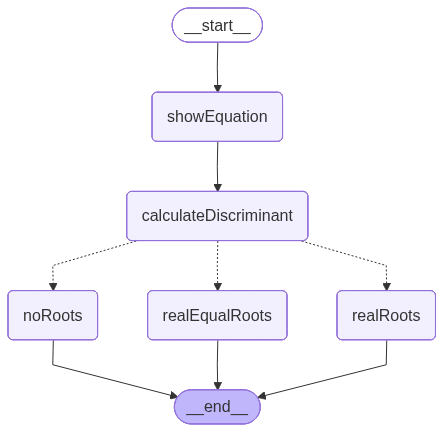

In [18]:
from IPython.display import Image
Image(EquationWorkflow.get_graph().draw_mermaid_png())

In [19]:
EquationWorkflow.invoke({'a': 4, 'b': -5, 'c': 1})

{'a': 4,
 'b': -5,
 'c': 1,
 'equation': '4x^2 + -5x + 1',
 'discriminant': 9,
 'result': 'The roots are 1.0 and 0.25'}

### LLM Workflow

In [20]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser, JsonOutputParser
from pydantic import BaseModel, Field

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [22]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [23]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

In [54]:
class SentimentSchema(BaseModel):
  sentiment : Literal["positive", "negative"] = Field(description = "Sentiment of the review")

class DiagnosisSchema(BaseModel):
  issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description = "The category of issue mentioned in the review")
  issue_description: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description = "The Emotional tone exppressed by the user")
  urgency: Literal["low", "medium", "high"] = Field(description = "How Urgent or critical the issue appears to be")

In [27]:
class SentimentState(TypedDict):
  review:str
  sentiment: Literal["positive", "negative"]
  diagnosis: dict
  response: str

In [58]:
review1 = "I had a fantastic experience with xyz. The team was incredibly friendly, knowledgeable, and efficient. They made the entire process smooth and stress-free. I will definitely be using their services again in the future. Highly recommended!"
review2 = "I arrived for my 12:00 PM appointment and wasn't seen until 1:30 PM. The front desk staff was unapologetic and rude about the massive delay."
review3 = "Every time I try to open the app, it immediately crashes on the splash screen. I've uninstalled and reinstalled it three times with no luck. Using an iPhone 14 Pro."

In [42]:
def findSentiment(state: SentimentState):
    review = state['review']

    pydanticParser = PydanticOutputParser(pydantic_object=SentimentSchema)
    prompt = PromptTemplate(
        template="""
        For the following review, find out the sentiment.
        {format_instructions}
        Review:
        {review}
        """,
        input_variables=["review"],
        partial_variables={
            "format_instructions":
            pydanticParser.get_format_instructions()
        }
    )

    chain = prompt | model | pydanticParser
    sentiment = chain.invoke({"review": review})

    return {"sentiment": sentiment.sentiment}

In [46]:
def checkCondition(state: SentimentState) -> Literal['positiveReponse', 'runDiagnostics']:
  if state['sentiment'] == 'positive':
    return 'positiveReponse'
  else:
    return 'runDiagnostics'


In [49]:
def positiveReponse(state: SentimentState):
  review = state['review']
  prompt = PromptTemplate(
      template ="""
      Write a warm thank-you and grateful message in response to this review:
      Review:
      {review}
      """,
      input_variables= ["review"]
  )
  parser = StrOutputParser()
  chain = prompt | model | parser
  response = chain.invoke({"review": review})
  return {"response": response}

In [55]:
def runDiagnostics(state: SentimentState):
    review = state['review']

    pydanticParser = PydanticOutputParser(pydantic_object=DiagnosisSchema)
    prompt = PromptTemplate(
        template="""
        Diagnose this negative review and return issue_type, tone and urgency:
        {format_instructions}
        Review:
        {review}
        """,
        input_variables=["review"],
        partial_variables={
            "format_instructions":
            pydanticParser.get_format_instructions()
        }
    )

    chain = prompt | model | pydanticParser
    diagnosis = chain.invoke({"review": review})

    return {"diagnosis": diagnosis.model_dump()}

In [63]:
def negativeResponse(state):
    review = state["review"]
    diagnosis = state["diagnosis"]

    issue_type = diagnosis["issue_type"]
    issue_description = diagnosis["issue_description"]
    urgency = diagnosis["urgency"]

    prompt = PromptTemplate(
        template="""
        You are a customer support assistant.

        Review:
        {review}

        Diagnosis:
        - Issue Type: {issue_type}
        - User Emotion: {issue_description}
        - Urgency: {urgency}

        Write an empathetic, professional,
        helpful and polite response to this review.
        """,
        input_variables=[
            "review",
            "issue_type",
            "issue_description",
            "urgency"
        ]
    )

    parser = StrOutputParser()

    chain = prompt | model | parser

    response = chain.invoke({
        "review": review,
        "issue_type": issue_type,
        "issue_description": issue_description,
        "urgency": urgency
    })

    return {
        "response": response
    }

In [67]:
graph = StateGraph(SentimentState)

graph.add_node('findSentiment', findSentiment)
graph.add_node('positiveReponse', positiveReponse)
graph.add_node('runDiagnostics', runDiagnostics)
graph.add_node('negativeResponse', negativeResponse)

graph.add_edge(START, 'findSentiment')
graph.add_conditional_edges('findSentiment', checkCondition)
graph.add_edge('positiveReponse', END)
graph.add_edge('runDiagnostics', 'negativeResponse')
graph.add_edge('negativeResponse', END)

SentimentWorkflow = graph.compile()

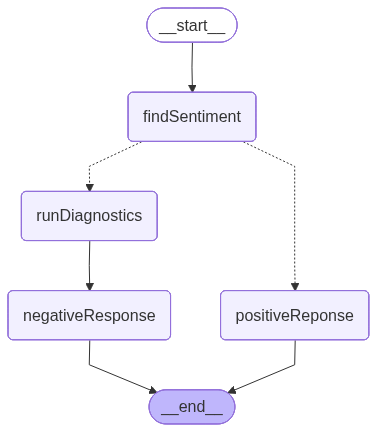

In [68]:
from IPython.display import Image
Image(SentimentWorkflow.get_graph().draw_mermaid_png())

In [69]:
SentimentWorkflow.invoke({'review': review1})

{'review': 'I had a fantastic experience with xyz. The team was incredibly friendly, knowledgeable, and efficient. They made the entire process smooth and stress-free. I will definitely be using their services again in the future. Highly recommended!',
 'sentiment': 'positive',
 'response': 'Thank you so much for your wonderful review! 🌟 We’re absolutely thrilled to hear that you had such a positive experience with us—your kind words mean a lot to our entire team. It’s truly special to know that our friendly, knowledgeable, and efficient service made your journey smooth and stress-free. We’re so glad we could help, and we’d be honored to serve you again in the future. Thank you for your trust and for sharing your experience—we’re grateful to be part of your journey! 💛'}

In [70]:
SentimentWorkflow.invoke({'review': review2})

{'review': "I arrived for my 12:00 PM appointment and wasn't seen until 1:30 PM. The front desk staff was unapologetic and rude about the massive delay.",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'UX',
  'issue_description': 'frustrated',
  'urgency': 'high'},
 'response': "Dear [Customer's Name],\n\nThank you for taking the time to share your experience with us. We're truly sorry to hear that your appointment was delayed and that you felt frustrated during your visit—especially with the wait time and the way the front desk staff interacted with you. That’s not the experience we aim to provide, and we sincerely apologize for the inconvenience and disappointment this caused.\n\nWe understand how important timely care is, and we’re committed to improving both our scheduling processes and the overall patient experience. Your feedback has been logged and will be shared with our front desk and operations teams to identify what went wrong and how we can prevent it in the future

In [71]:
SentimentWorkflow.invoke({'review': review3})

{'review': "Every time I try to open the app, it immediately crashes on the splash screen. I've uninstalled and reinstalled it three times with no luck. Using an iPhone 14 Pro.",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug',
  'issue_description': 'frustrated',
  'urgency': 'high'},
 'response': "Thank you for taking the time to share your experience with us — we're truly sorry to hear that you're having such a frustrating issue with the app. We completely understand how disappointing it must be to repeatedly encounter a crash right at the splash screen, especially after trying to reinstall it multiple times.\n\nYour feedback is incredibly valuable to us, and we're already looking into this issue with urgency. Since you're using an iPhone 14 Pro, we're taking special note to ensure there are no device-specific compatibility or performance issues that may be contributing to the crash.\n\nWe’re committed to getting this resolved quickly and will be working closely with ou